# BP-Adam vs Predictive Coding: catastrophic-forgetting architecture study

This notebook presents the matched-architecture experiment for `784-100-10`, `784-500-10`, `784-1000-10`, and `784-300-300-10`.

- Both methods use Adam with learning rate `0.001` and identical initial weights.
- Task 1 contains MNIST classes 0–5; task 2 contains classes 6–9.
- Recovery occurs only after task-2 training and uses the disjoint task-1 batches specified in the loaded experiment configuration.
- Every trajectory point is evaluated on the merged task-1/task-2 test set.
- A sigmoid hidden unit is called functionally dead when its test-set activation standard deviation is at most `1e-3`, or its mean activation derivative is at most `1e-3`.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.analysis.plot_architecture_comparison import (
    load_report,
    plot_accuracy_trajectories,
    plot_per_class_accuracy,
    plot_confusion_matrices,
    plot_parameter_drift,
    plot_parameter_drift_comparison,
    plot_dead_neurons,
)

RESULT_PATH = ROOT / 'results' / 'architecture_comparison' / 'results.json'
PLOT_DIR = ROOT / 'results' / 'architecture_comparison' / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
report = load_report(RESULT_PATH)
architectures = list(report['config']['architectures'])
print(f"Loaded {len(report['runs'])} runs from {RESULT_PATH}")

Loaded 8 runs from D:\CursorRepos\NMA_NeroAI\micro-learning\Catastrophically-Forgotten\results\architecture_comparison\results.json


## Experiment configuration and endpoint summary

In [2]:
config = report['config']
display(Markdown(
    f"**Optimizer:** {config['optimizer']} &nbsp; "
    f"**learning rate:** {config['learning_rate']} &nbsp; "
    f"**phase epochs:** {config['phase_epochs']} &nbsp; "
    f"**recovery:** {config['recovery_batches']}×{config['recovery_batch_size']} &nbsp; "
    f"**device:** {config['device']}"
))

header = '| Architecture | Method | T1 after T1 | T1 after T2 | T1 after recovery | T2 after recovery | Forgetting | Recovery gain |\n'
separator = '|---|---|---:|---:|---:|---:|---:|---:|\n'
rows = []
for run in report['runs']:
    s = run['summary']
    rows.append(
        f"| {run['architecture']} | {run['method']} | "
        f"{s['task1_at_task1_end']:.2f}% | {s['task1_at_task2_end']:.2f}% | "
        f"{s['task1_after_recovery']:.2f}% | {s['task2_after_recovery']:.2f}% | "
        f"{s['forgetting']:.2f} pp | {s['recovery_gain']:.2f} pp |"
    )
display(Markdown(header + separator + '\n'.join(rows)))

**Optimizer:** Adam &nbsp; **learning rate:** 0.001 &nbsp; **phase epochs:** 5 &nbsp; **recovery:** 10×64 &nbsp; **device:** cuda

| Architecture | Method | T1 after T1 | T1 after T2 | T1 after recovery | T2 after recovery | Forgetting | Recovery gain |
|---|---|---:|---:|---:|---:|---:|---:|
| 784-100-10 | BP-Adam | 92.22% | 0.22% | 9.33% | 79.00% | 92.00 pp | 9.11 pp |
| 784-100-10 | PC-Adam | 92.89% | 2.00% | 82.89% | 55.67% | 90.89 pp | 80.89 pp |
| 784-500-10 | BP-Adam | 94.00% | 0.00% | 9.33% | 79.67% | 94.00 pp | 9.33 pp |
| 784-500-10 | PC-Adam | 94.00% | 0.67% | 86.22% | 43.67% | 93.33 pp | 85.56 pp |
| 784-1000-10 | BP-Adam | 93.78% | 0.00% | 11.78% | 82.33% | 93.78 pp | 11.78 pp |
| 784-1000-10 | PC-Adam | 93.78% | 0.89% | 84.44% | 67.33% | 92.89 pp | 83.56 pp |
| 784-300-300-10 | BP-Adam | 92.00% | 0.00% | 0.00% | 57.67% | 92.00 pp | 0.00 pp |
| 784-300-300-10 | PC-Adam | 93.78% | 0.22% | 81.33% | 69.33% | 93.56 pp | 81.11 pp |

## Accuracy after every training iteration

The two vertical dotted lines mark the end of task 1 and task 2. The final purple iterations are the configured recovery batches.

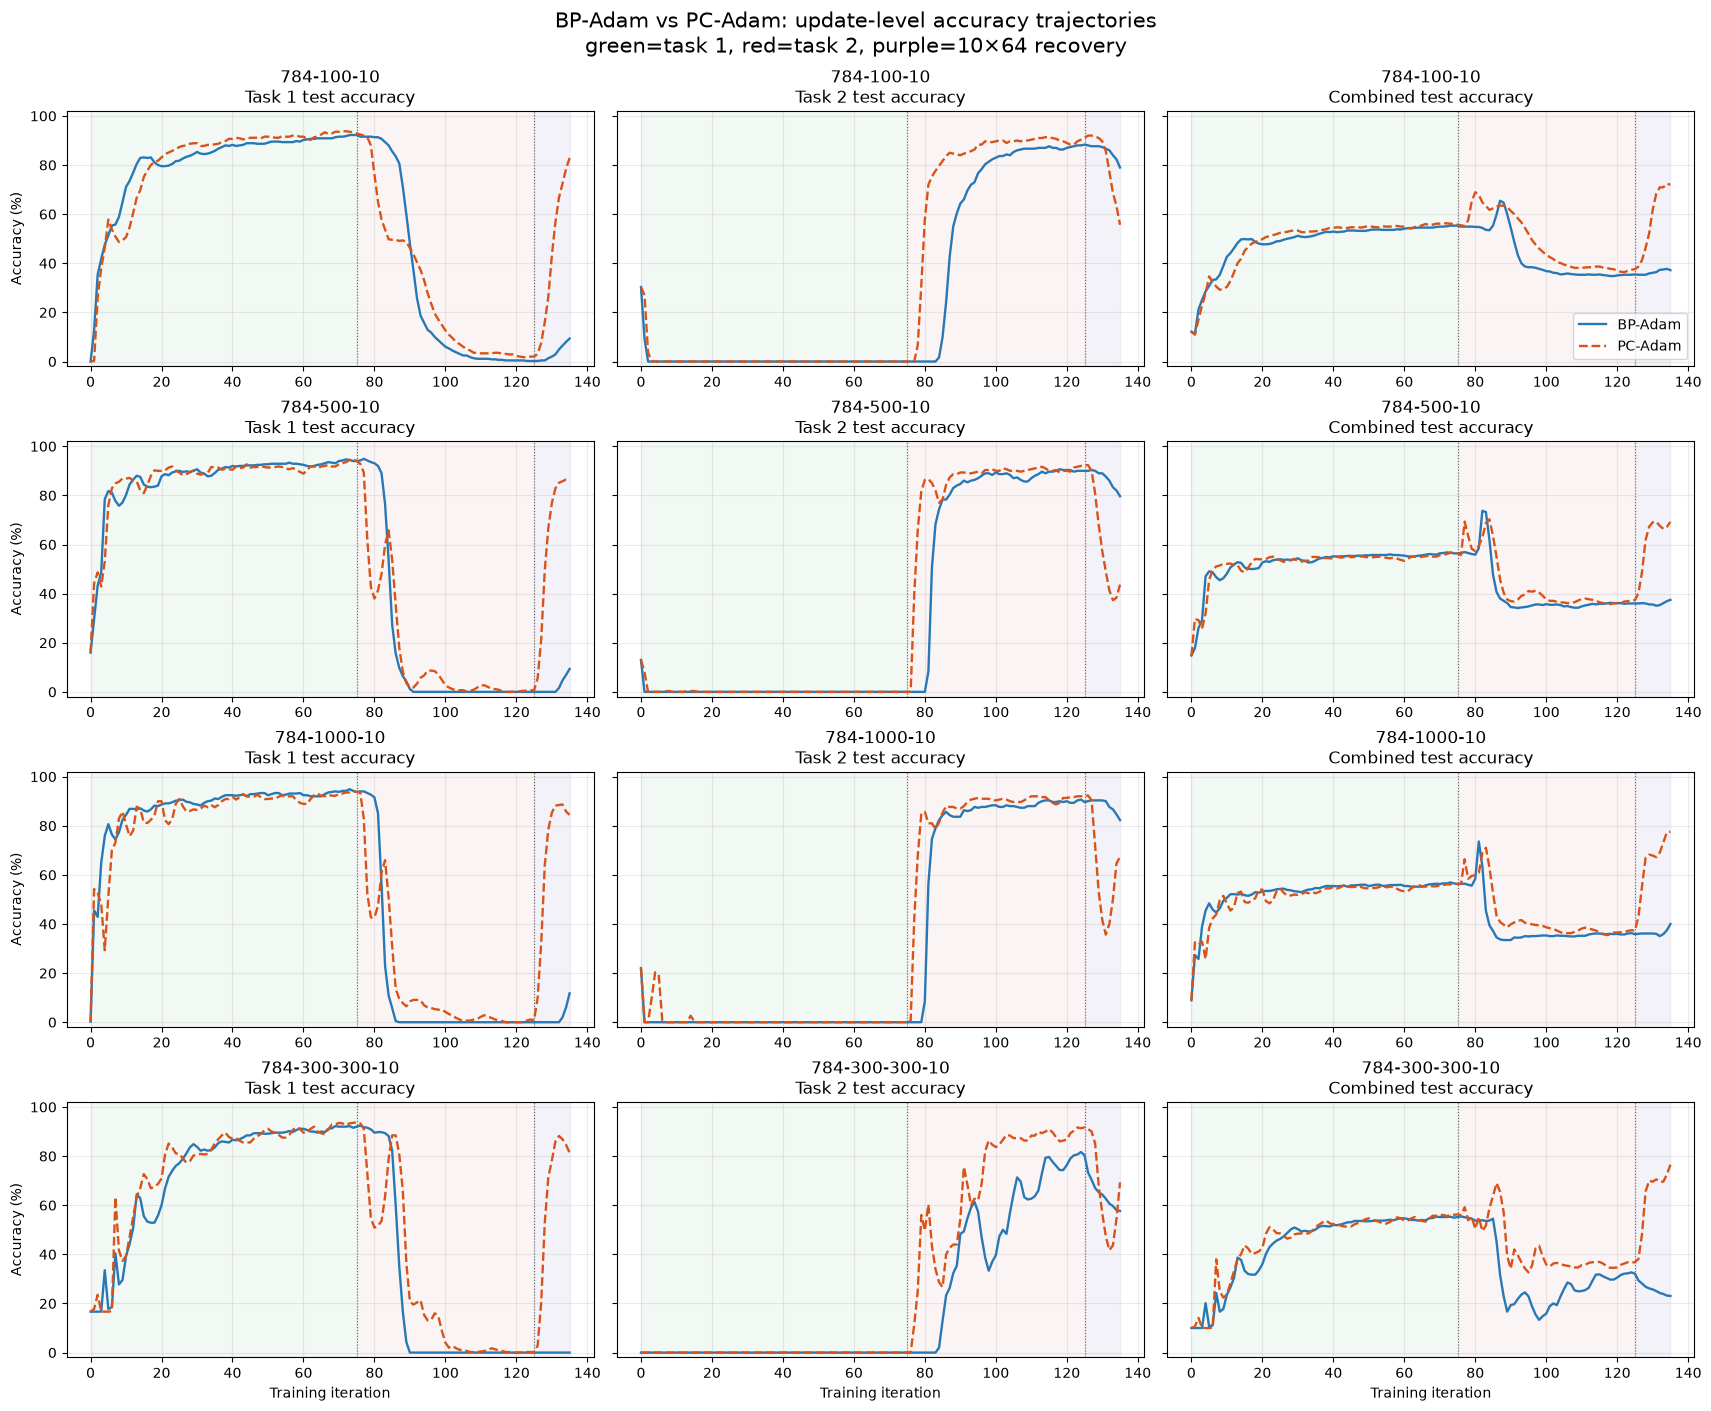

In [3]:
fig = plot_accuracy_trajectories(report)
fig.savefig(PLOT_DIR / 'accuracy_trajectories.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

## Per-class accuracy at the three stage boundaries

Green bars are task-1 classes (0–5); red bars are task-2 classes (6–9).

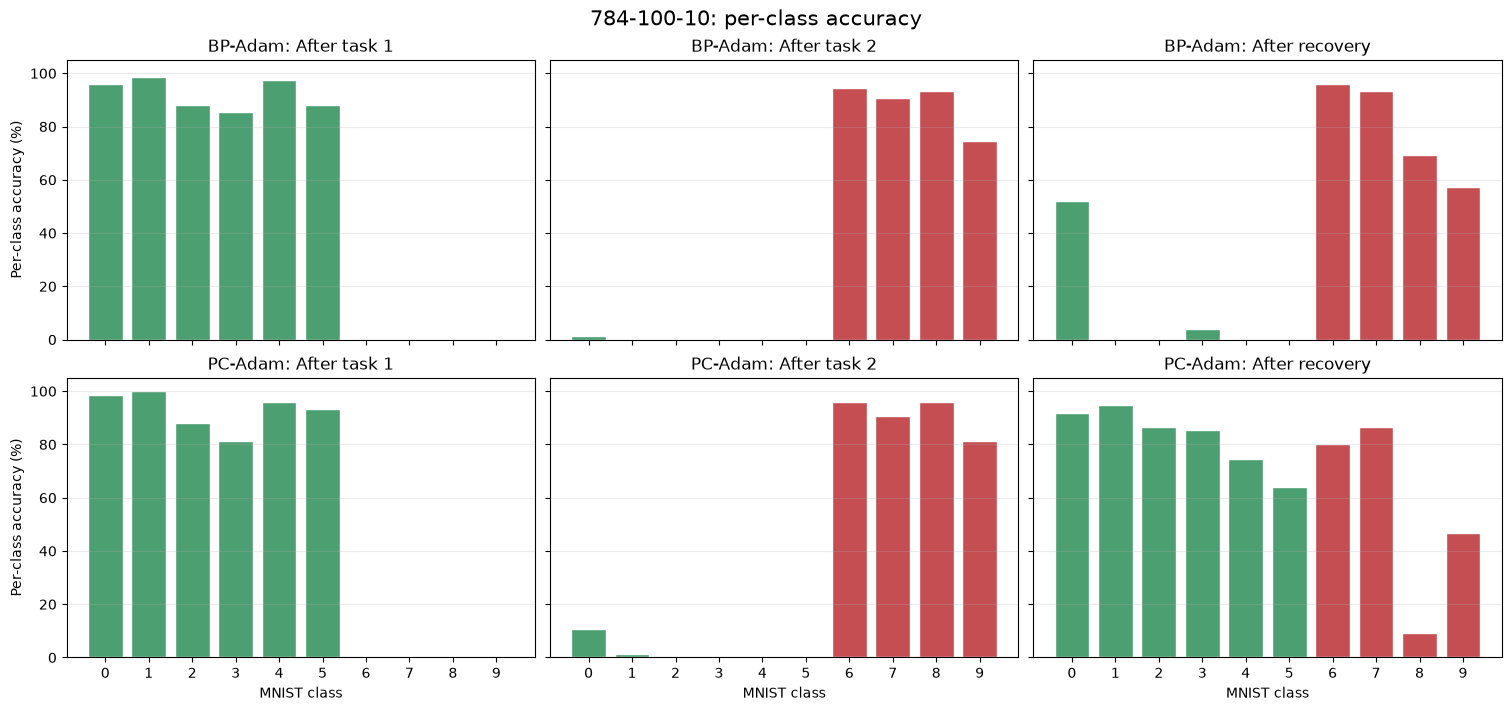

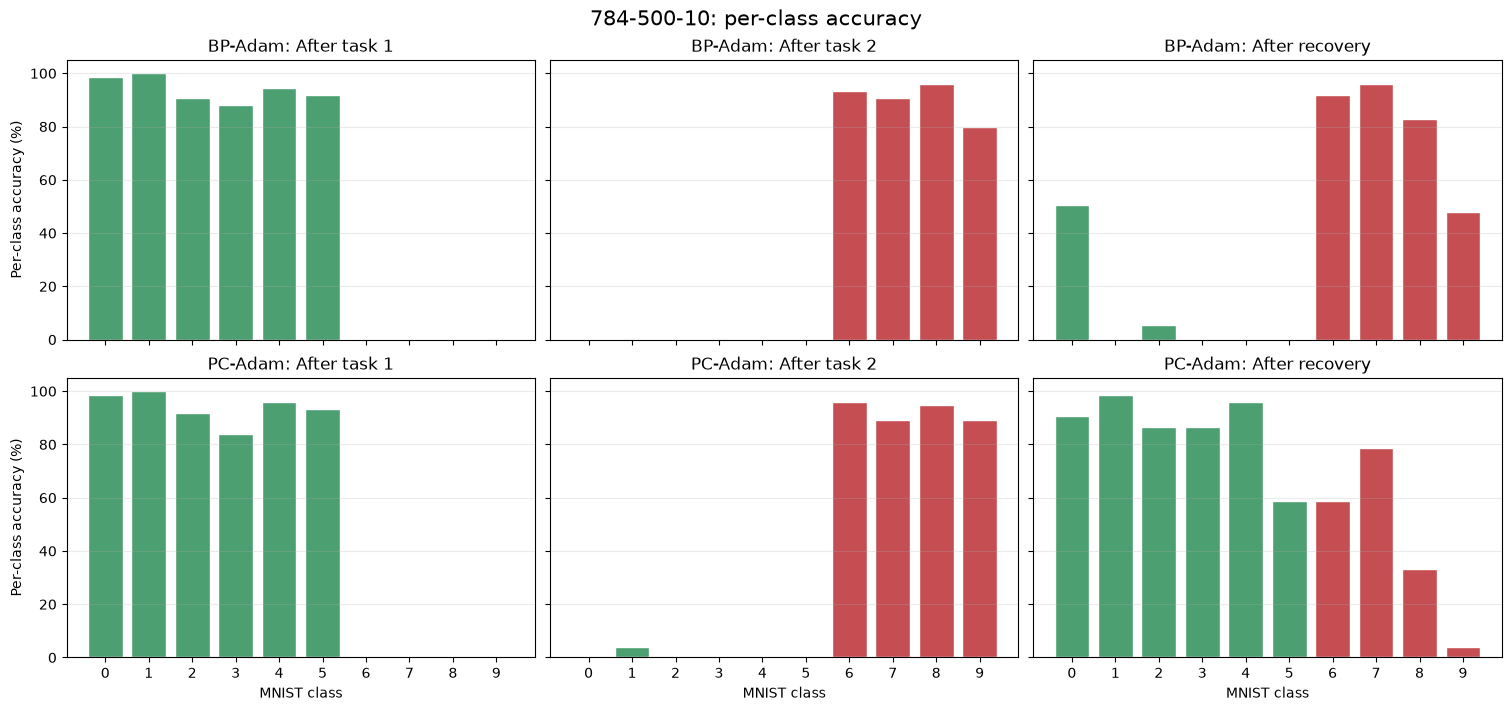

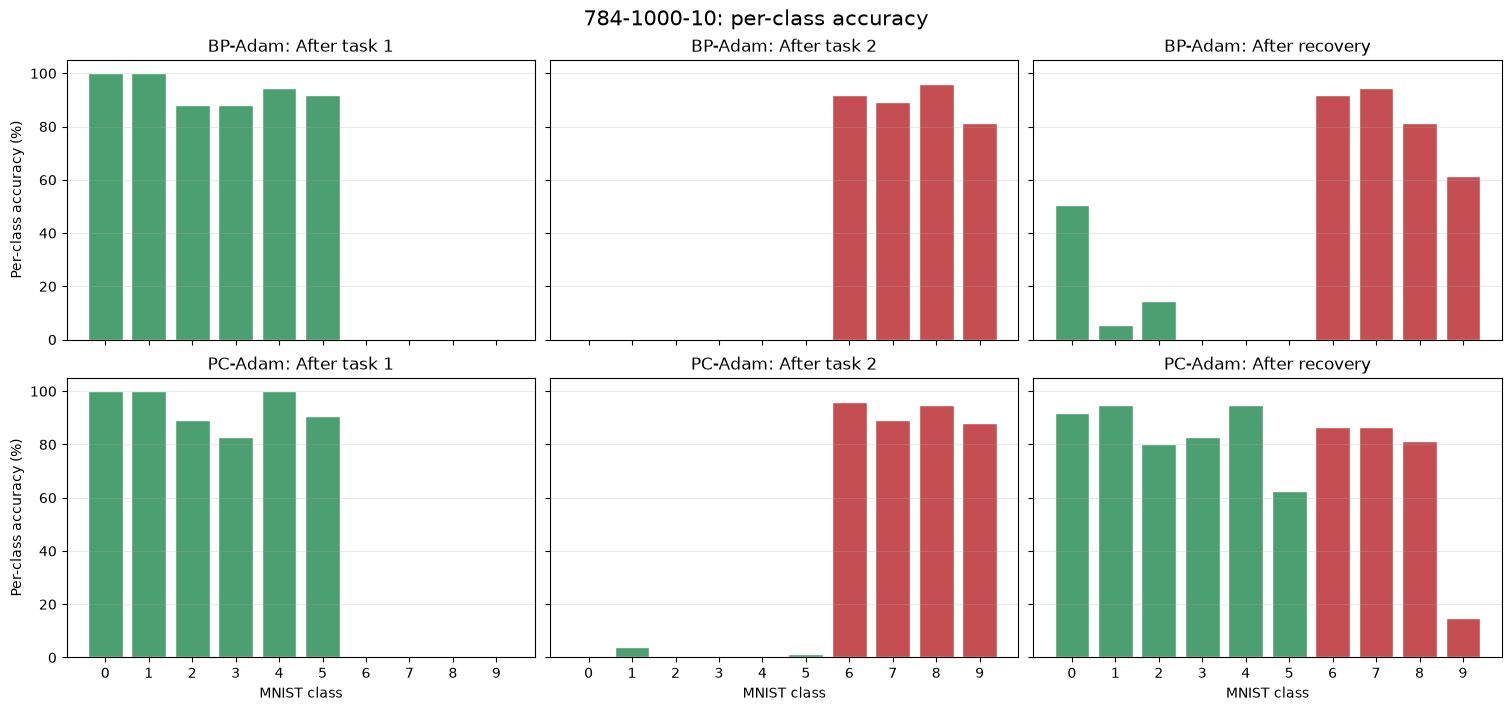

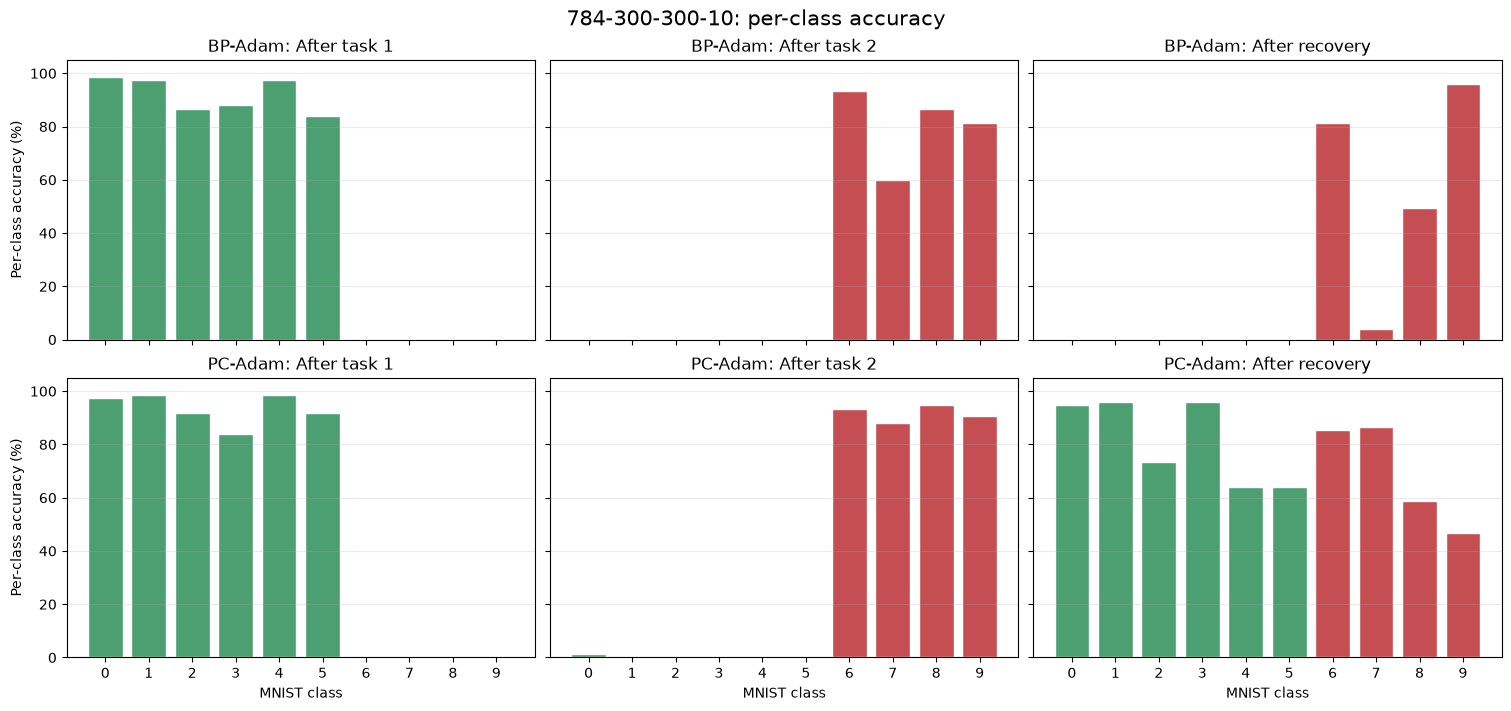

In [4]:
for architecture in architectures:
    fig = plot_per_class_accuracy(report, architecture)
    slug = architecture.replace('-', '_')
    fig.savefig(PLOT_DIR / f'per_class_accuracy_{slug}.png', dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(fig)

## Confusion matrices on the merged test set

Matrices are row-normalized. The orange separators divide task-1 and task-2 classes.

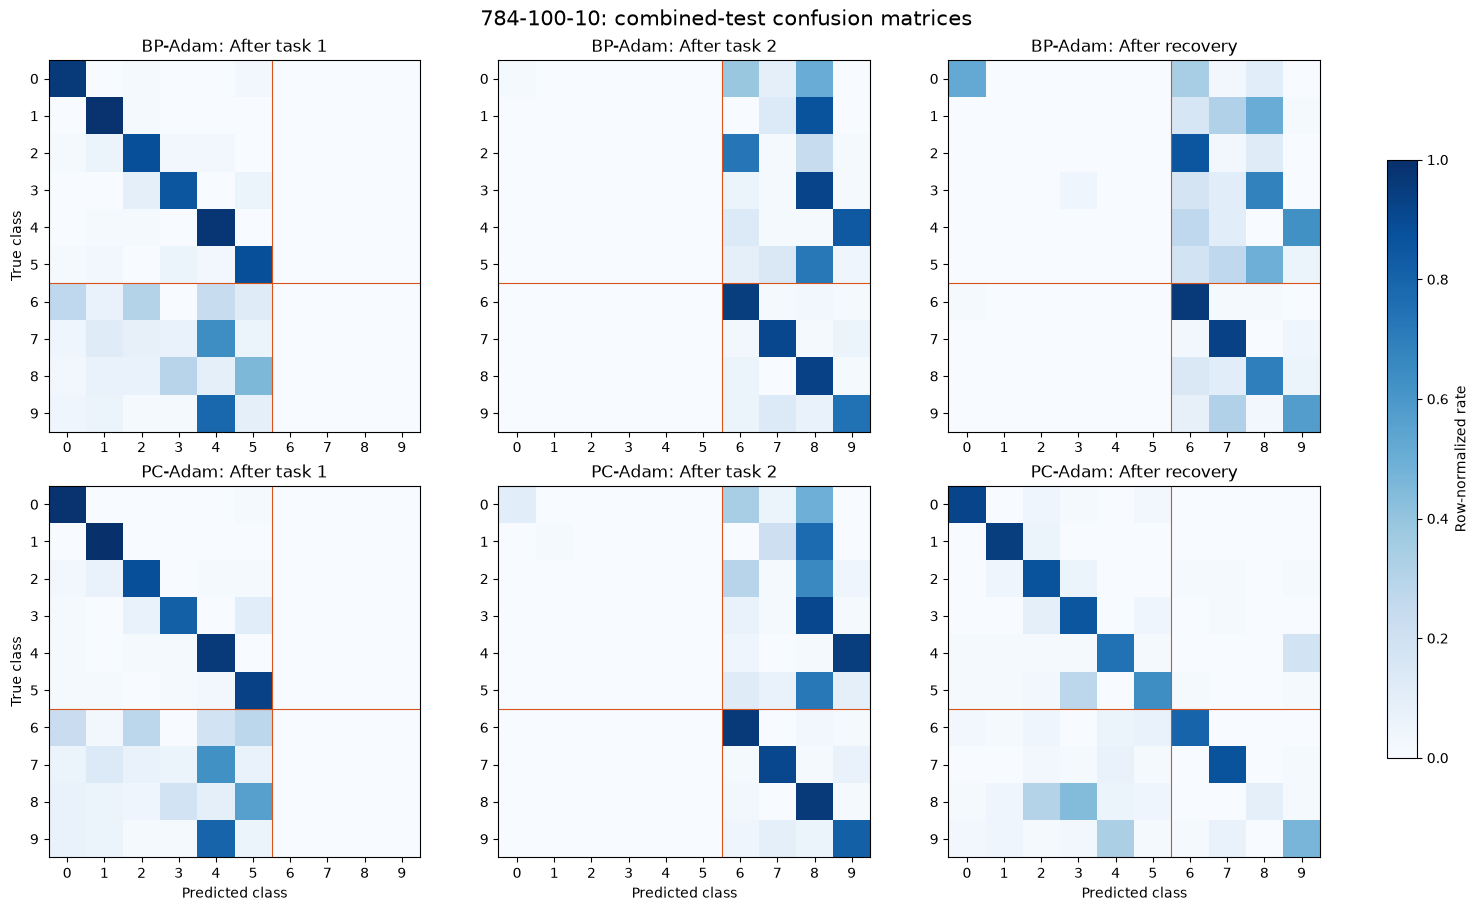

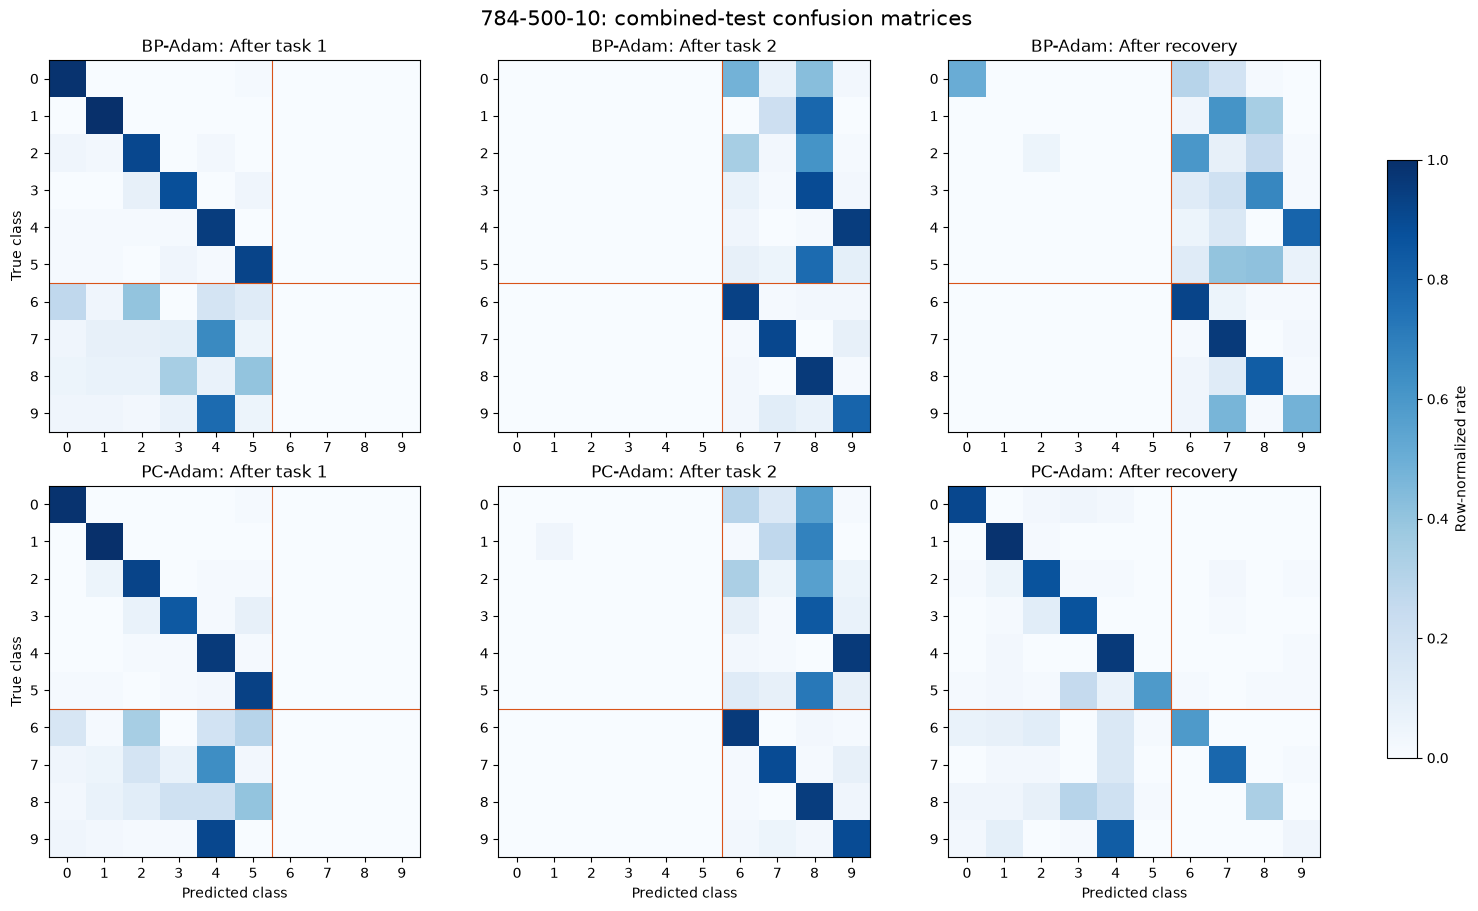

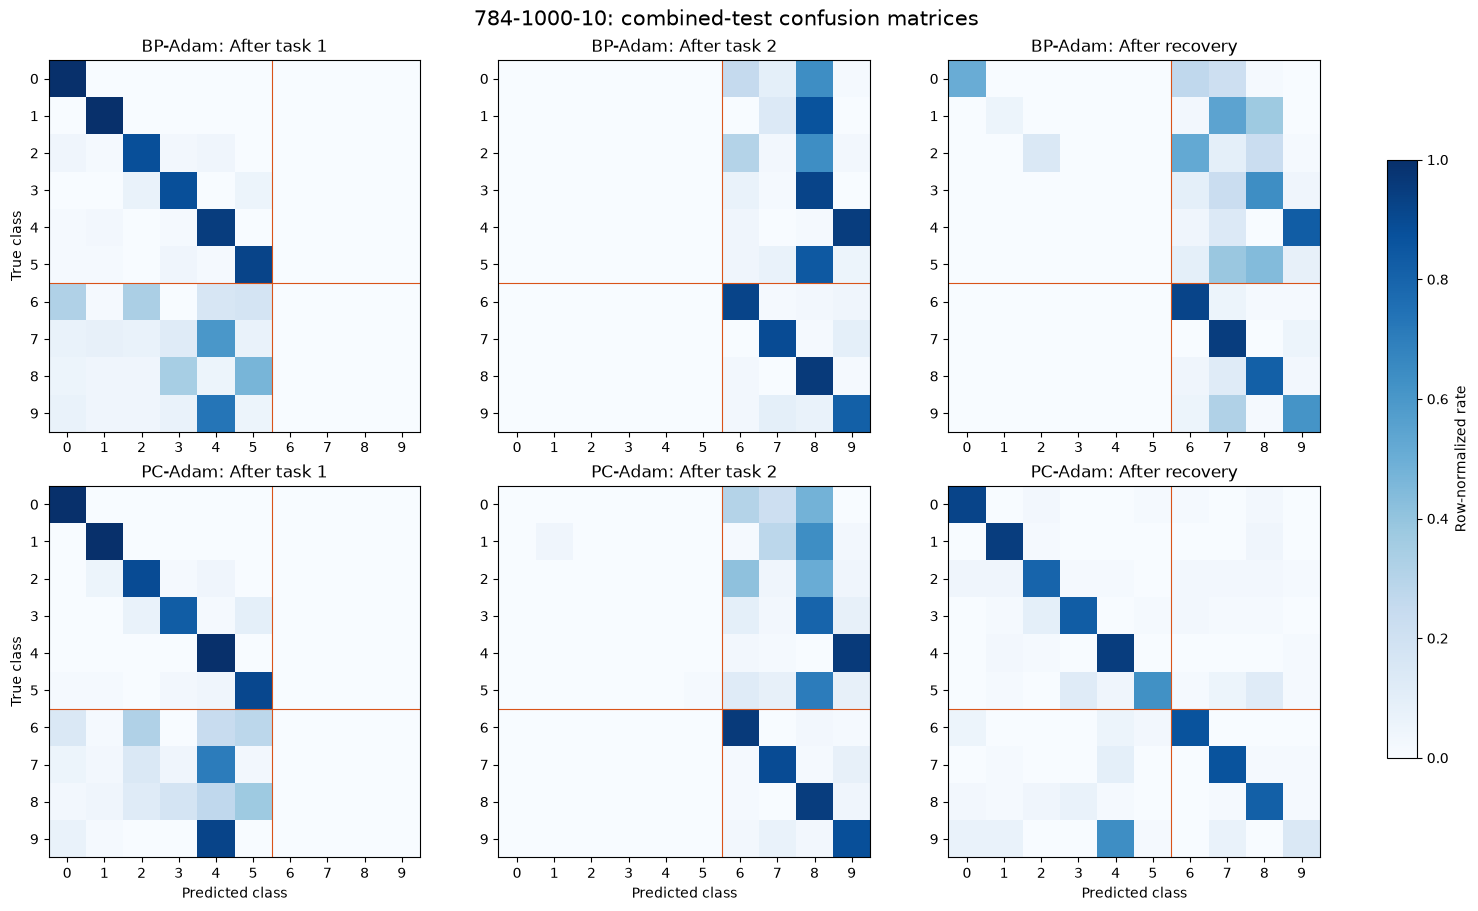

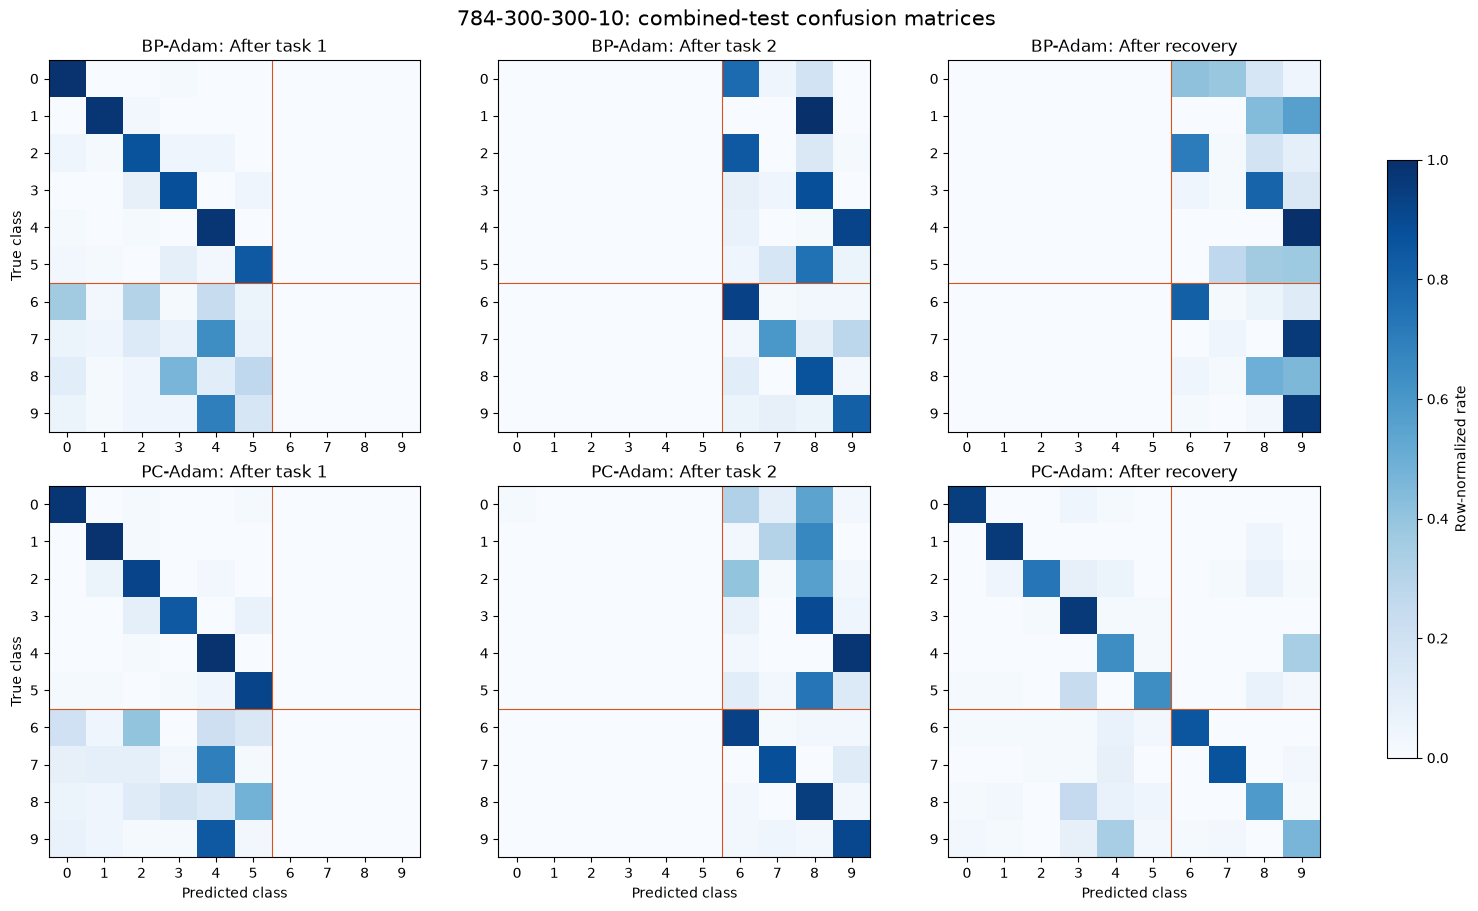

In [5]:
for architecture in architectures:
    fig = plot_confusion_matrices(report, architecture)
    slug = architecture.replace('-', '_')
    fig.savefig(PLOT_DIR / f'confusion_matrices_{slug}.png', dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(fig)

## Layer-wise parameter drift

Each bar is cumulative drift from the shared initialization, normalized by that layer's initial parameter norm.

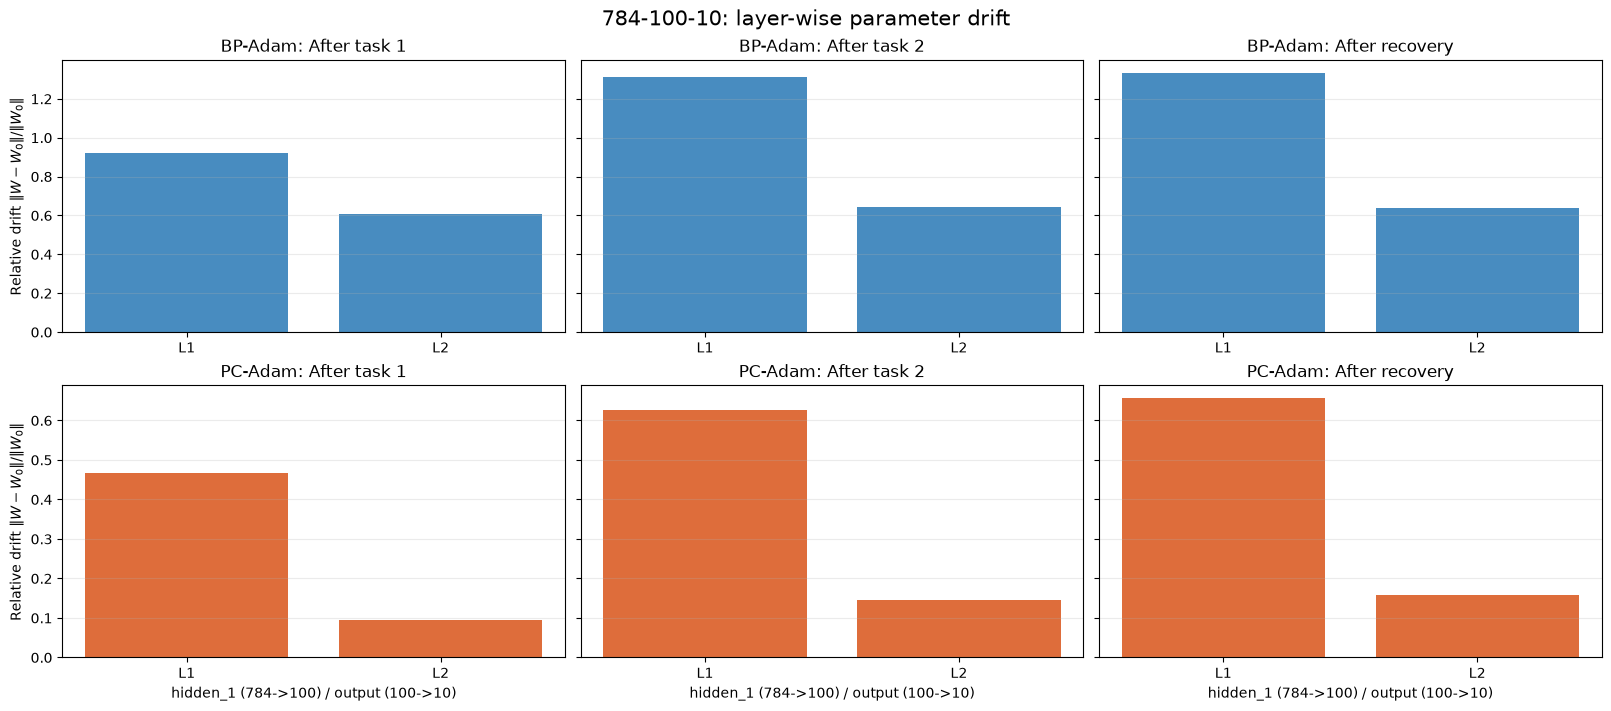

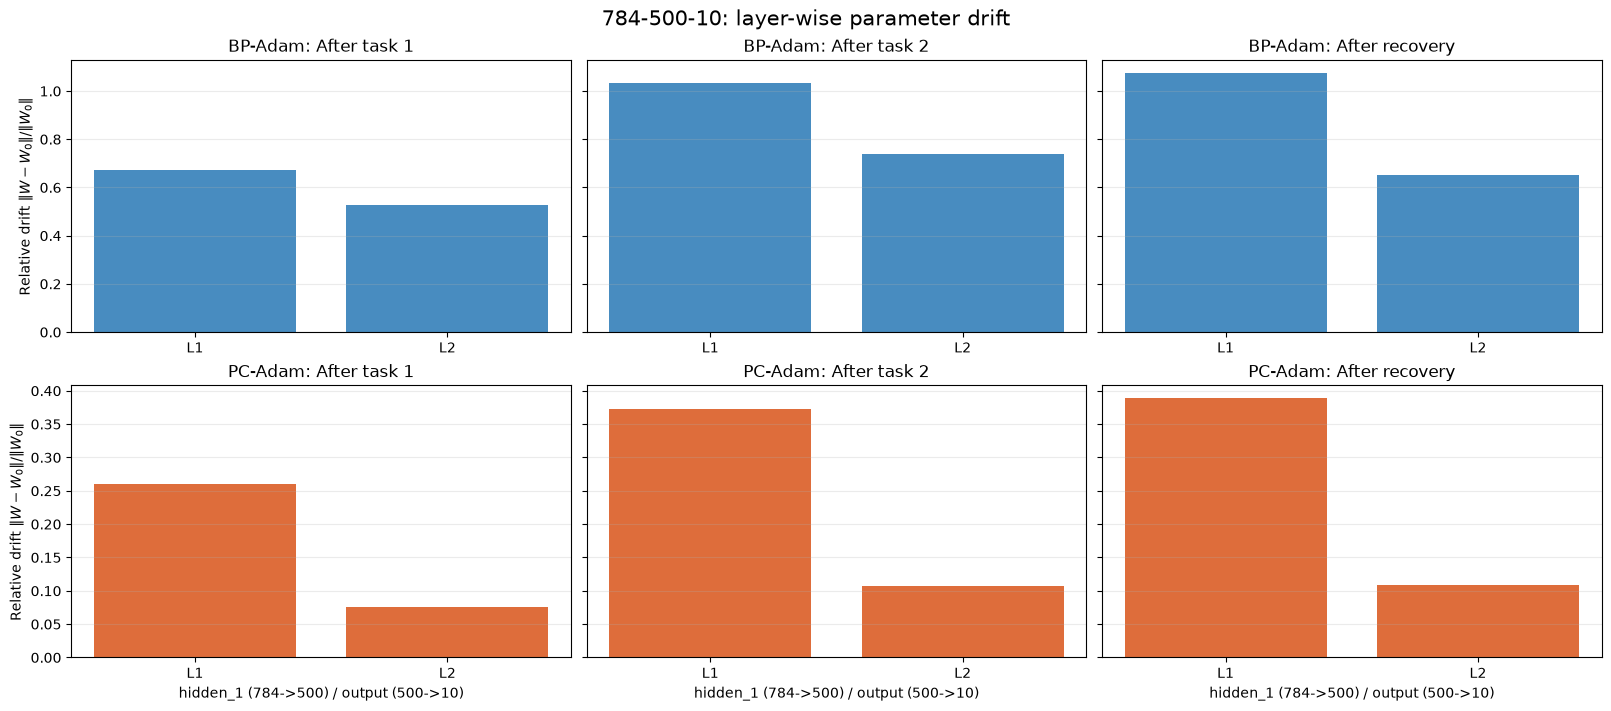

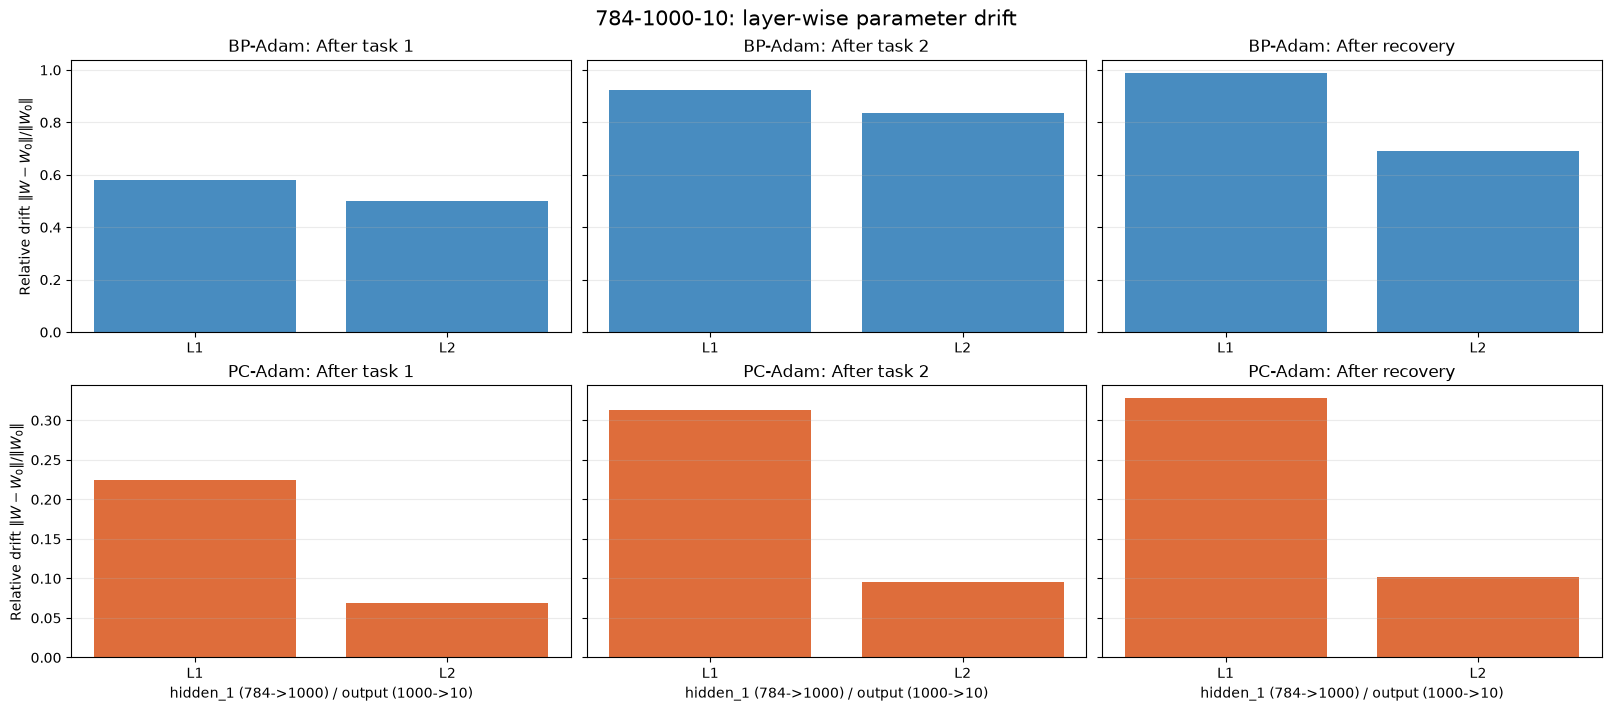

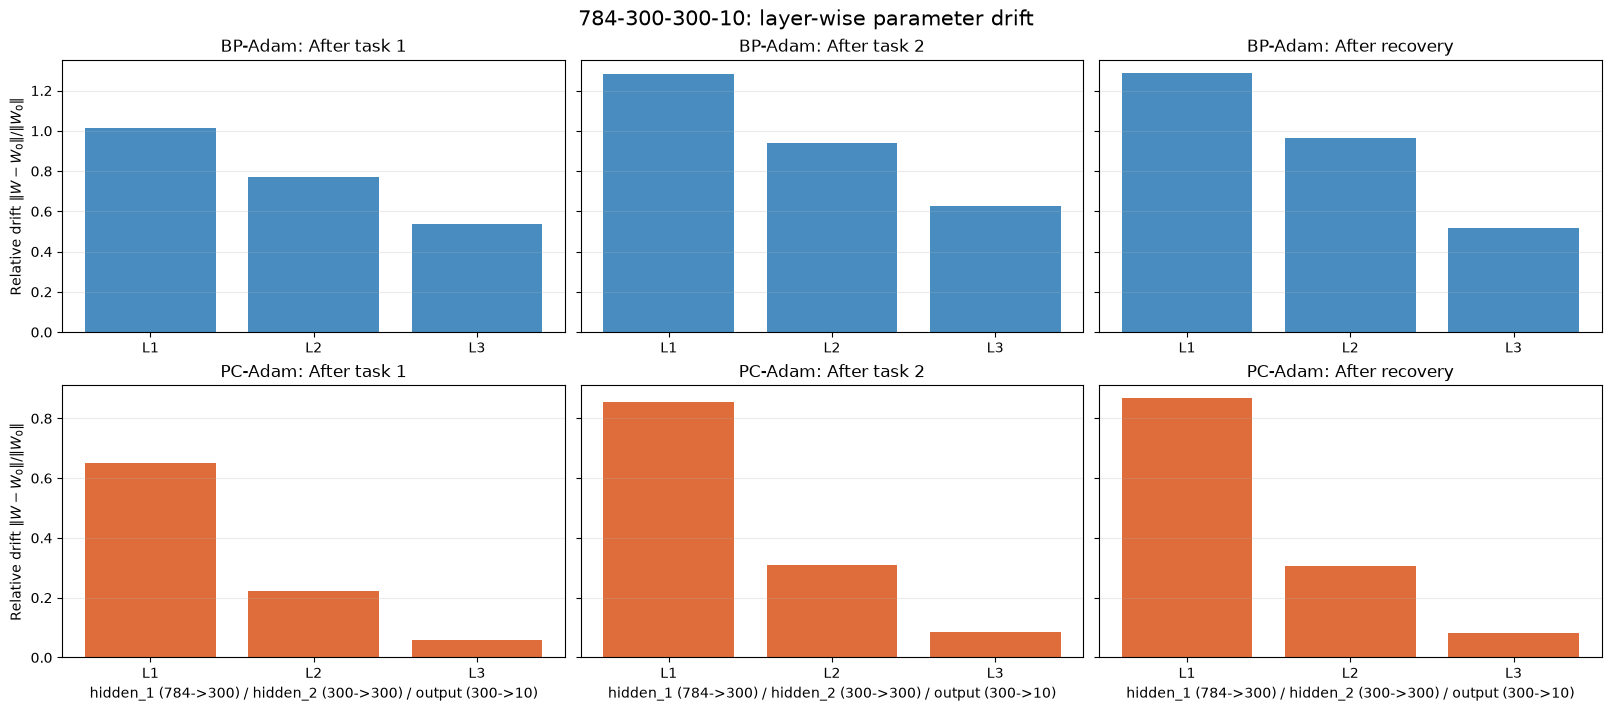

In [6]:
for architecture in architectures:
    fig = plot_parameter_drift(report, architecture)
    slug = architecture.replace('-', '_')
    fig.savefig(PLOT_DIR / f'parameter_drift_{slug}.png', dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(fig)

## Dead-neuron comparison after task 1 and task 2

For sigmoid networks, exact zero activation is not a useful definition. Here a neuron is functionally dead if it is almost invariant over the merged test set or has an almost-zero mean activation derivative.

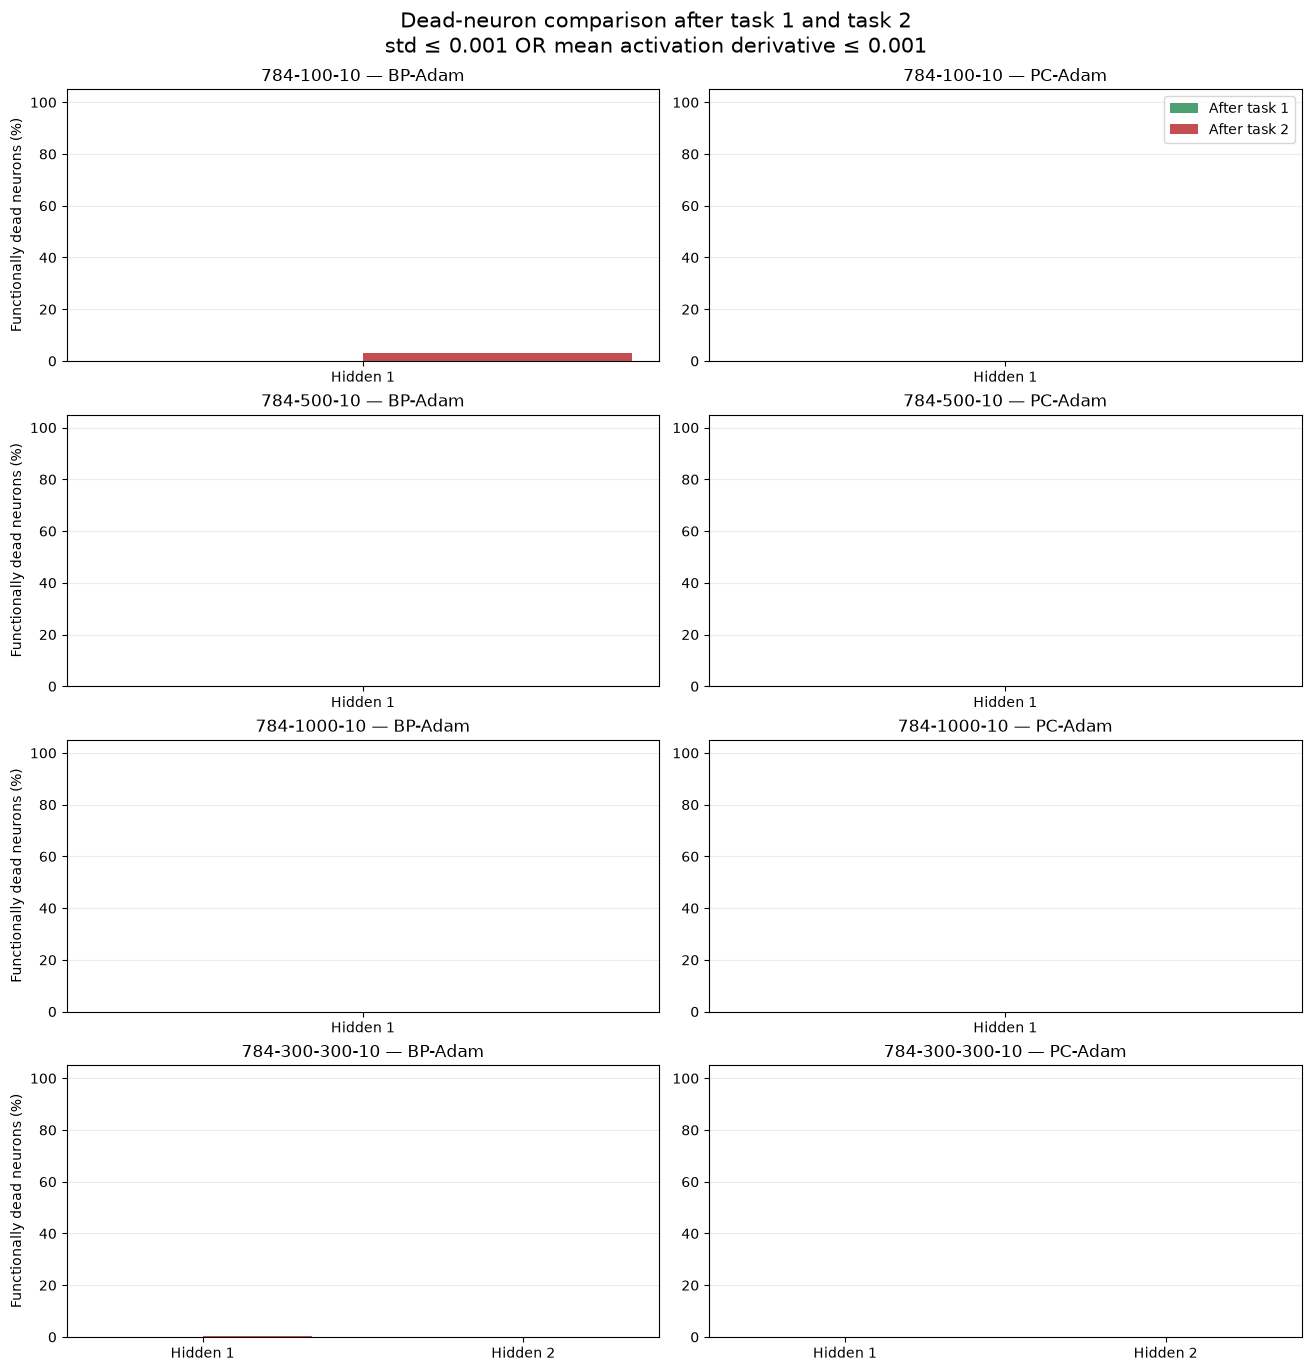

In [7]:
fig = plot_dead_neurons(report)
fig.savefig(PLOT_DIR / 'dead_neurons.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

## Reading the diagnostics

- A task-1 drop during the red task-2 region measures forgetting; a rise over the final purple iterations measures sample-efficient recovery.
- Per-class bars and confusion matrices reveal whether forgetting is class-specific or a global bias toward task-2 outputs.
- Large output-layer drift with stable hidden layers suggests readout interference; large hidden-layer drift suggests representational overwriting.
- An increase in dead-neuron rate from task 1 to task 2 indicates loss of usable representational capacity. If accuracy falls without more dead units, the cause is more likely weight-direction drift or output competition.

## Direct BP versus PC parameter-drift comparison

Each row is one architecture and the three columns show cumulative layer-wise drift from the shared initialization after task 1, task 2, and recovery. Blue bars are BP-Adam; orange bars are PC-Adam.

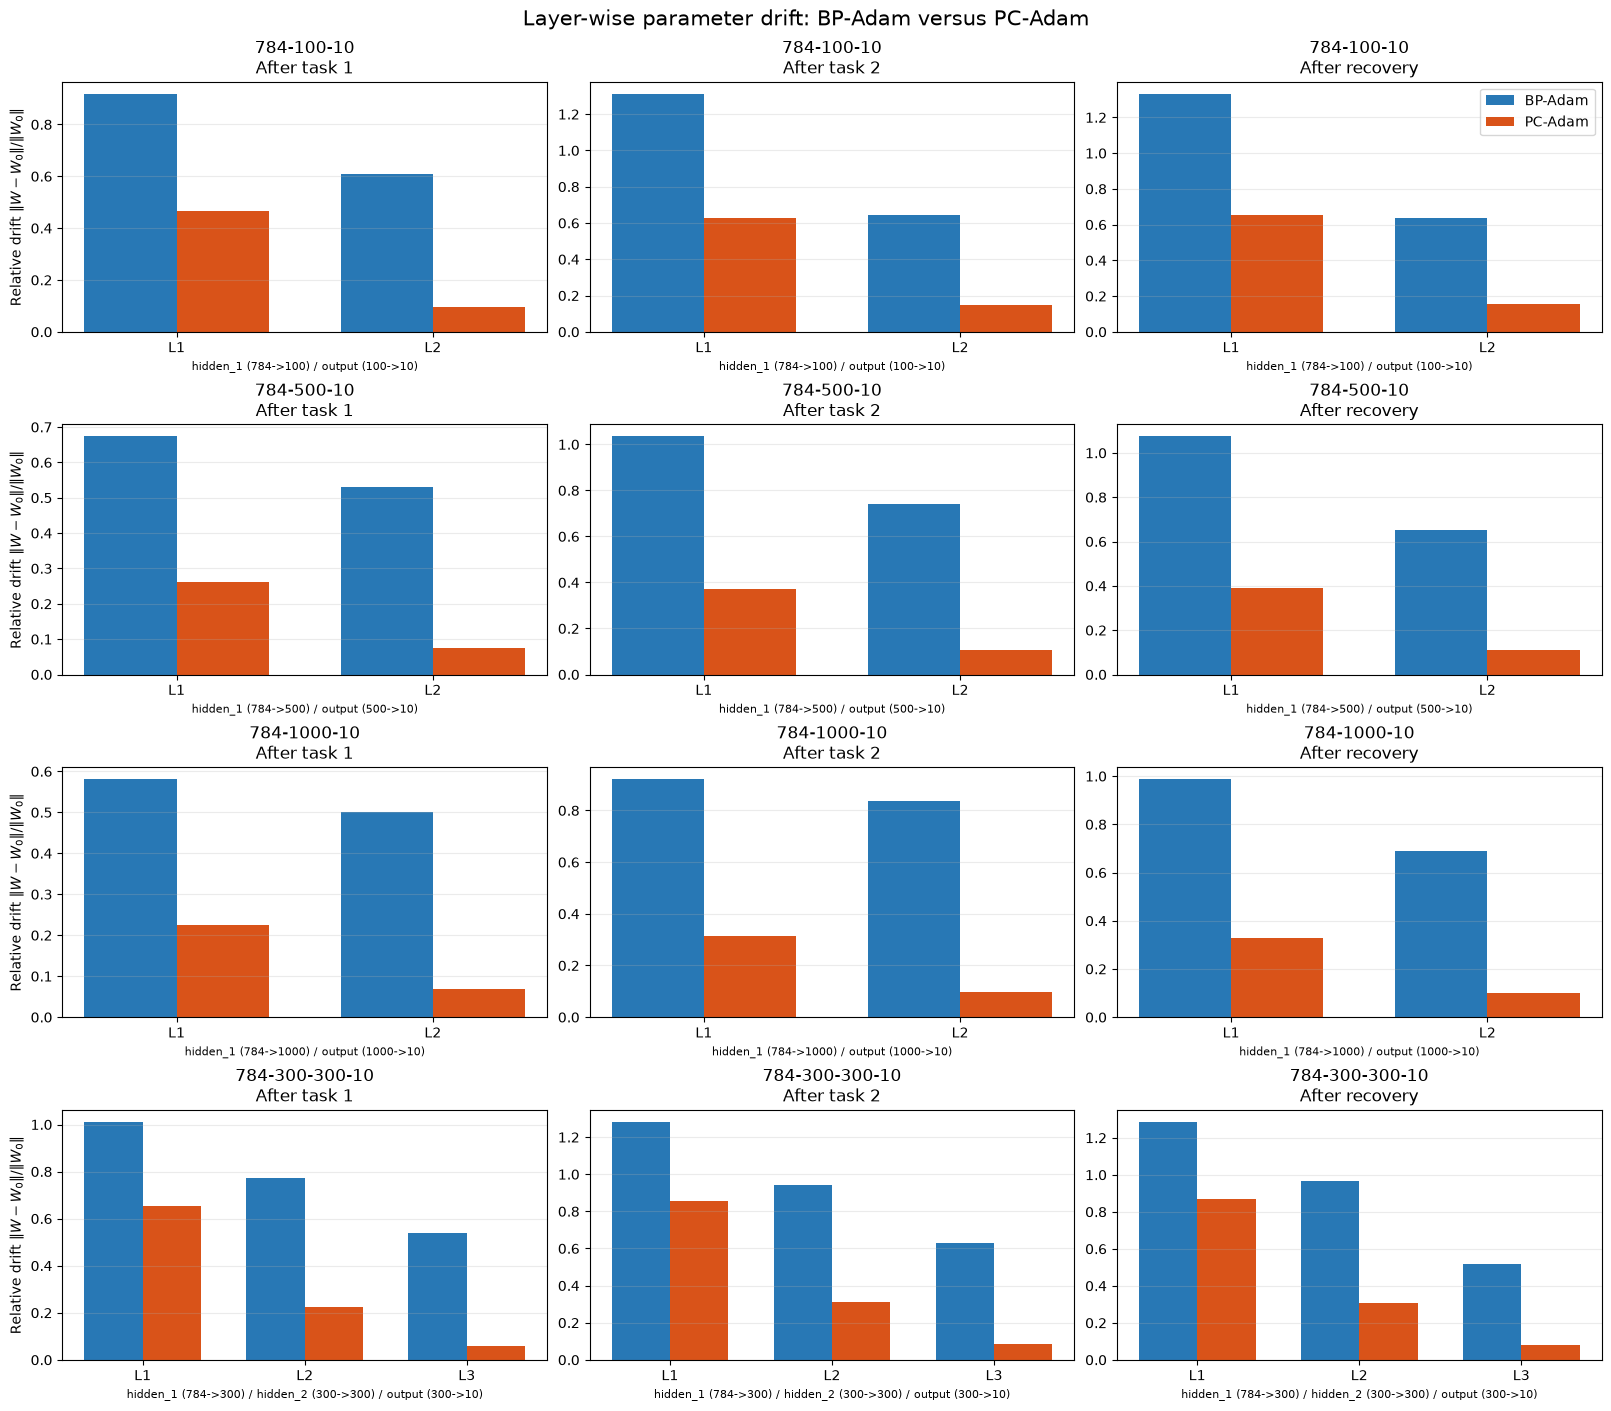

In [8]:
fig = plot_parameter_drift_comparison(report)
fig.savefig(PLOT_DIR / 'parameter_drift_bp_vs_pc.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)